In [1]:
#Importing necessary libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

#Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Cleanup the Data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


c:\Users\sujay\anaconda3\envs\python_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [50]:
Job_Country = 'United States'

df_Data_Jobs = df[df['job_country'] == Job_Country]

In [51]:
df_Skills = df_Data_Jobs.explode('job_skills')

df_Skills[['job_title', 'job_skills']]

df_Skills_count = df_Skills.groupby(['job_skills', 'job_title_short']).size()

df_Skills_count = df_Skills_count.reset_index(name = 'skill_count')

df_Skills_count.sort_values(by = 'skill_count', ascending = False, inplace = True)

df_Skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


In [53]:
Job_Titles = df_Skills_count['job_title_short'].unique().tolist()

Job_Titles = sorted(Job_Titles[:3])

Job_Titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

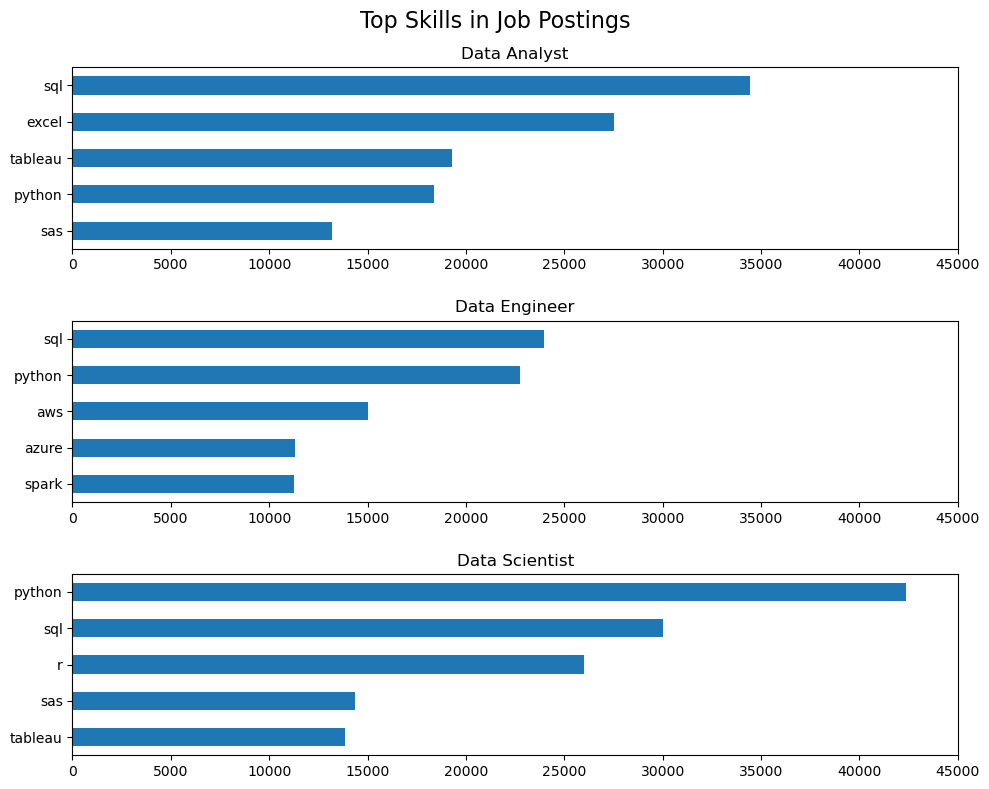

In [54]:
fig, ax = plt.subplots(len(Job_Titles), 1)

for i, Job_Title in enumerate(Job_Titles):
    df_Plot = df_Skills_count[df_Skills_count['job_title_short'] == Job_Title].head(5)
    df_Plot.plot(kind = 'barh', x = 'job_skills', y = 'skill_count', ax = ax[i], title = Job_Title, legend = False)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlim(0, 45000)

fig.set_size_inches(10, 8)
fig.suptitle(f'Top Skills in Job Postings', fontsize = 16)
fig.tight_layout(h_pad = 2)
plt.show()    

In [55]:
df_job_title_count = df_Data_Jobs['job_title_short'].value_counts().reset_index(name = 'total_jobs')

df_skills_percentage = pd.merge(df_Skills_count, df_job_title_count, how = 'left', on = 'job_title_short')

df_skills_percentage['skill_percentage'] = df_skills_percentage['skill_count'] / df_skills_percentage['total_jobs'] * 100

df_skills_percentage

,job_skills,job_title_short,skill_count,total_jobs,skill_percentage
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


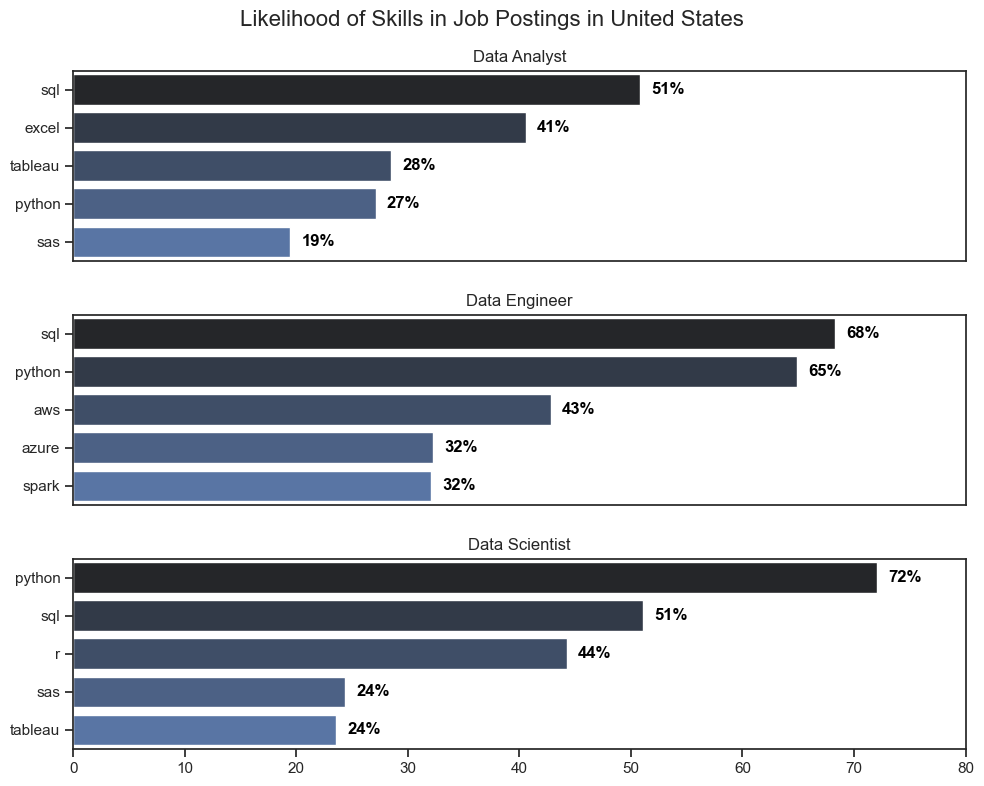

In [68]:
fig, ax = plt.subplots(len(Job_Titles), 1)


sns.set_theme(style = 'ticks')

for i, Job_Title in enumerate(Job_Titles):
    df_Plot = df_skills_percentage[df_skills_percentage['job_title_short'] == Job_Title].head(5)
    sns.barplot(data = df_Plot, x = 'skill_percentage', y = 'job_skills', ax = ax[i], hue = 'job_skills', palette = 'dark:b', legend = False)
    ax[i].set_title(Job_Title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0, 80)

    for n, v in enumerate(df_Plot['skill_percentage']):
        ax[i].text(v + 1, n, f'{v:.0f}%', color = 'black', va = 'center', fontweight = 'bold', fontsize = 12)

    if i != len(Job_Titles) -1:
        ax[i].set_xticks([])

fig.set_size_inches(10, 8)
fig.suptitle(f'Likelihood of Skills in Job Postings in {Job_Country}', fontsize = 16)
fig.tight_layout(h_pad = 2)
plt.show()